# Airline Passenger Satisfaction Prediction

## Project Overview

This project analyses airline passenger satisfaction using machine learning techniques. 
The goal is to identify the factors that most influence passenger satisfaction and build 
a classification model that predicts whether a passenger is satisfied or neutral/dissatisfied.

**Dataset:** Airline Passenger Satisfaction  
**Source:** https://www.kaggle.com/datasets/teejmahal20/airline-passenger-satisfaction  
**Problem type:** Binary classification  
**Target variable:** `satisfaction` (`satisfied`, `neutral or dissatisfied`)  
**Dataset dimensions:** 103,904 rows and 25 original columns (22 predictive features after removing two identifiers and the target)

Airlines collect large volumes of passenger feedback across multiple service touchpoints, including travel experience, delays, onboard services, and booking processes. This project uses machine learning to identify patterns associated with passenger satisfaction and dissatisfaction.

The analysis includes data exploration, preprocessing, model development, model comparison, hyperparameter tuning, and evaluation. The final objective is to understand which factors have the strongest relationship with passenger satisfaction and develop a reliable classification model that can support data-driven service improvement decisions.

In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", context="notebook")

# Look for the dataset in the project folder
data_candidates = [
    Path("data/train.csv"),
    Path("train.csv"),
]

DATA_PATH = next((path for path in data_candidates if path.exists()), None)

if DATA_PATH is None:
    raise FileNotFoundError(
        "train.csv was not found. Place it inside the 'data' folder "
        "or in the same folder as this notebook."
    )

df = pd.read_csv(DATA_PATH)

print("Dataset file:", DATA_PATH)
print("Dataset shape:", df.shape)

print("\nFirst 10 rows:")
display(df.head(10))

print("\nTarget distribution:")
display(df["satisfaction"].value_counts())

Dataset file: train.csv
Dataset shape: (103904, 25)

First 10 rows:


,Unnamed: 0,id,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,...,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
0,0,70172,Male,Loyal Customer,13,Personal Travel,Eco Plus,460,3,4,...,5,4,3,4,4,5,5,25,18.0,neutral or dissatisfied
1,1,5047,Male,disloyal Customer,25,Business travel,Business,235,3,2,...,1,1,5,3,1,4,1,1,6.0,neutral or dissatisfied
2,2,110028,Female,Loyal Customer,26,Business travel,Business,1142,2,2,...,5,4,3,4,4,4,5,0,0.0,satisfied
3,3,24026,Female,Loyal Customer,25,Business travel,Business,562,2,5,...,2,2,5,3,1,4,2,11,9.0,neutral or dissatisfied
4,4,119299,Male,Loyal Customer,61,Business travel,Business,214,3,3,...,3,3,4,4,3,3,3,0,0.0,satisfied
5,5,111157,Female,Loyal Customer,26,Personal Travel,Eco,1180,3,4,...,1,3,4,4,4,4,1,0,0.0,neutral or dissatisfied
6,6,82113,Male,Loyal Customer,47,Personal Travel,Eco,1276,2,4,...,2,3,3,4,3,5,2,9,23.0,neutral or dissatisfied
7,7,96462,Female,Loyal Customer,52,Business travel,Business,2035,4,3,...,5,5,5,5,4,5,4,4,0.0,satisfied
8,8,79485,Female,Loyal Customer,41,Business travel,Business,853,1,2,...,1,1,2,1,4,1,2,0,0.0,neutral or dissatisfied
9,9,65725,Male,disloyal Customer,20,Business travel,Eco,1061,3,3,...,2,2,3,4,4,3,2,0,0.0,neutral or dissatisfied



Target distribution:


satisfaction
neutral or dissatisfied    58879
satisfied                  45025
Name: count, dtype: int64

## Step 2: Exploratory Data Analysis

The exploratory analysis checks data quality, class balance, numeric relationships, passenger age, and satisfaction across travel classes. These outputs establish which preprocessing decisions are necessary and whether accuracy alone would be sufficient for evaluation.

SUMMARY STATISTICS


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Unnamed: 0,103904.0,NaN,NaN,NaN,51951.5,29994.645522,0.0,25975.75,51951.5,77927.25,103903.0
id,103904.0,NaN,NaN,NaN,64924.210502,37463.812252,1.0,32533.75,64856.5,97368.25,129880.0
Gender,103904,2,Female,52727,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Customer Type,103904,2,Loyal Customer,84923,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age,103904.0,NaN,NaN,NaN,39.379706,15.114964,7.0,27.0,40.0,51.0,85.0
Type of Travel,103904,2,Business travel,71655,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Class,103904,3,Business,49665,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Flight Distance,103904.0,NaN,NaN,NaN,1189.448375,997.147281,31.0,414.0,843.0,1743.0,4983.0
Inflight wifi service,103904.0,NaN,NaN,NaN,2.729683,1.327829,0.0,2.0,3.0,4.0,5.0
Departure/Arrival time convenient,103904.0,NaN,NaN,NaN,3.060296,1.525075,0.0,2.0,3.0,4.0,5.0



MISSING VALUES ABOVE ZERO


Arrival Delay in Minutes    310
dtype: int64

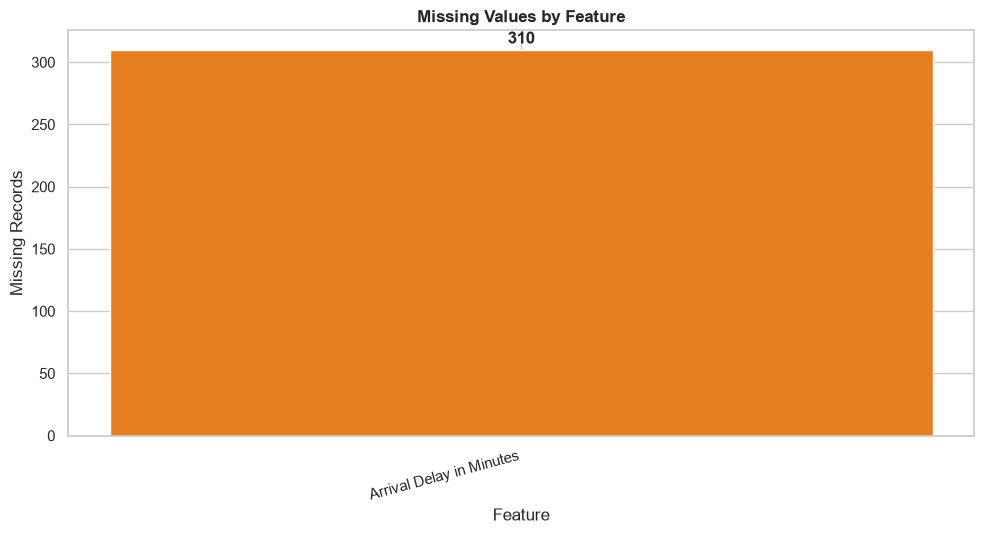

In [3]:
print("SUMMARY STATISTICS")
display(df.describe(include="all").transpose())

missing_counts = df.isnull().sum().sort_values(ascending=False)

print("\nMISSING VALUES ABOVE ZERO")
display(missing_counts[missing_counts > 0])

plot_missing = missing_counts[missing_counts > 0]

plt.figure(figsize=(10, 5.5))
plt.bar(plot_missing.index, plot_missing.values, color="#E67E22")

plt.title("Missing Values by Feature", fontweight="bold")
plt.ylabel("Missing Records")
plt.xlabel("Feature")

plt.xticks(rotation=15, ha="right")

for i, value in enumerate(plot_missing.values):
    plt.text(
        i,
        value + 5,
        f"{value:,}",
        ha="center",
        fontweight="bold"
    )

plt.tight_layout()
plt.show()

CLASS DISTRIBUTION
neutral or dissatisfied: 58,879 (56.67%)
satisfied: 45,025 (43.33%)


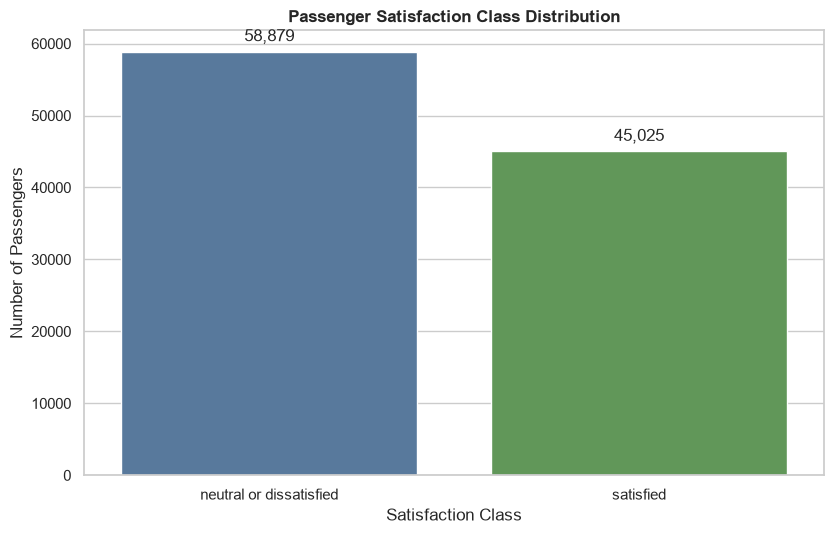

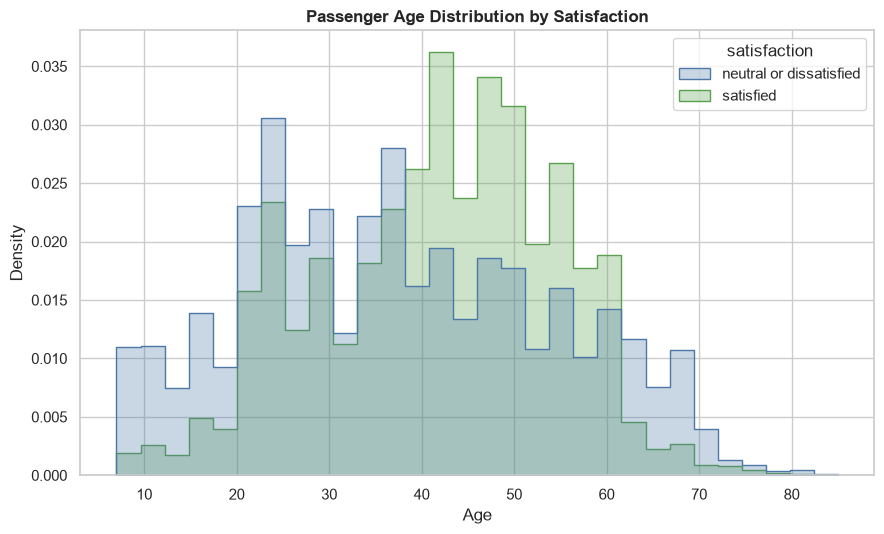

SATISFACTION PERCENTAGE WITHIN EACH TRAVEL CLASS


satisfaction,neutral or dissatisfied,satisfied
Class,,
Business,30.57,69.43
Eco,81.39,18.61
Eco Plus,75.39,24.61


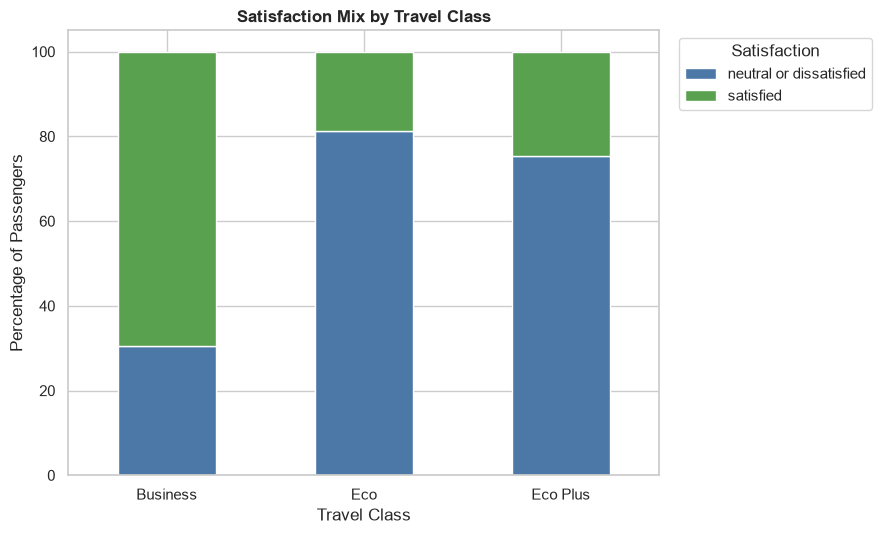

In [4]:
target_counts = df["satisfaction"].value_counts()
target_pct = df["satisfaction"].value_counts(normalize=True).mul(100)

print("CLASS DISTRIBUTION")
for label in target_counts.index:
    print(f"{label}: {target_counts[label]:,} ({target_pct[label]:.2f}%)")

# Passenger satisfaction class distribution
plt.figure(figsize=(8.5, 5.5))
ax = sns.countplot(
    data=df,
    x="satisfaction",
    palette=["#4C78A8", "#59A14F"]
)

plt.title("Passenger Satisfaction Class Distribution", fontweight="bold")
plt.xlabel("Satisfaction Class")
plt.ylabel("Number of Passengers")

for patch in ax.patches:
    ax.annotate(
        f"{int(patch.get_height()):,}",
        (patch.get_x() + patch.get_width() / 2, patch.get_height()),
        ha="center",
        va="bottom",
        xytext=(0, 5),
        textcoords="offset points"
    )

plt.tight_layout()
plt.show()


# Age distribution by satisfaction
plt.figure(figsize=(9, 5.5))

sns.histplot(
    data=df,
    x="Age",
    hue="satisfaction",
    bins=30,
    stat="density",
    common_norm=False,
    element="step",
    alpha=0.30,
    palette=["#4C78A8", "#59A14F"]
)

plt.title("Passenger Age Distribution by Satisfaction", fontweight="bold")
plt.xlabel("Age")
plt.ylabel("Density")

plt.tight_layout()
plt.show()


# Satisfaction percentage within each travel class
class_satisfaction = pd.crosstab(
    df["Class"],
    df["satisfaction"],
    normalize="index"
).mul(100)

print("SATISFACTION PERCENTAGE WITHIN EACH TRAVEL CLASS")
display(class_satisfaction.round(2))

class_satisfaction.plot(
    kind="bar",
    stacked=True,
    figsize=(9, 5.5),
    color=["#4C78A8", "#59A14F"]
)

plt.title("Satisfaction Mix by Travel Class", fontweight="bold")
plt.xlabel("Travel Class")
plt.ylabel("Percentage of Passengers")
plt.xticks(rotation=0)
plt.legend(
    title="Satisfaction",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

NUMERIC FEATURES INCLUDED IN THE CORRELATION HEATMAP
Age, Flight Distance, Inflight wifi service, Departure/Arrival time convenient, Ease of Online booking, Gate location, Food and drink, Online boarding, Seat comfort, Inflight entertainment, On-board service, Leg room service, Baggage handling, Checkin service, Inflight service, Cleanliness, Departure Delay in Minutes, Arrival Delay in Minutes


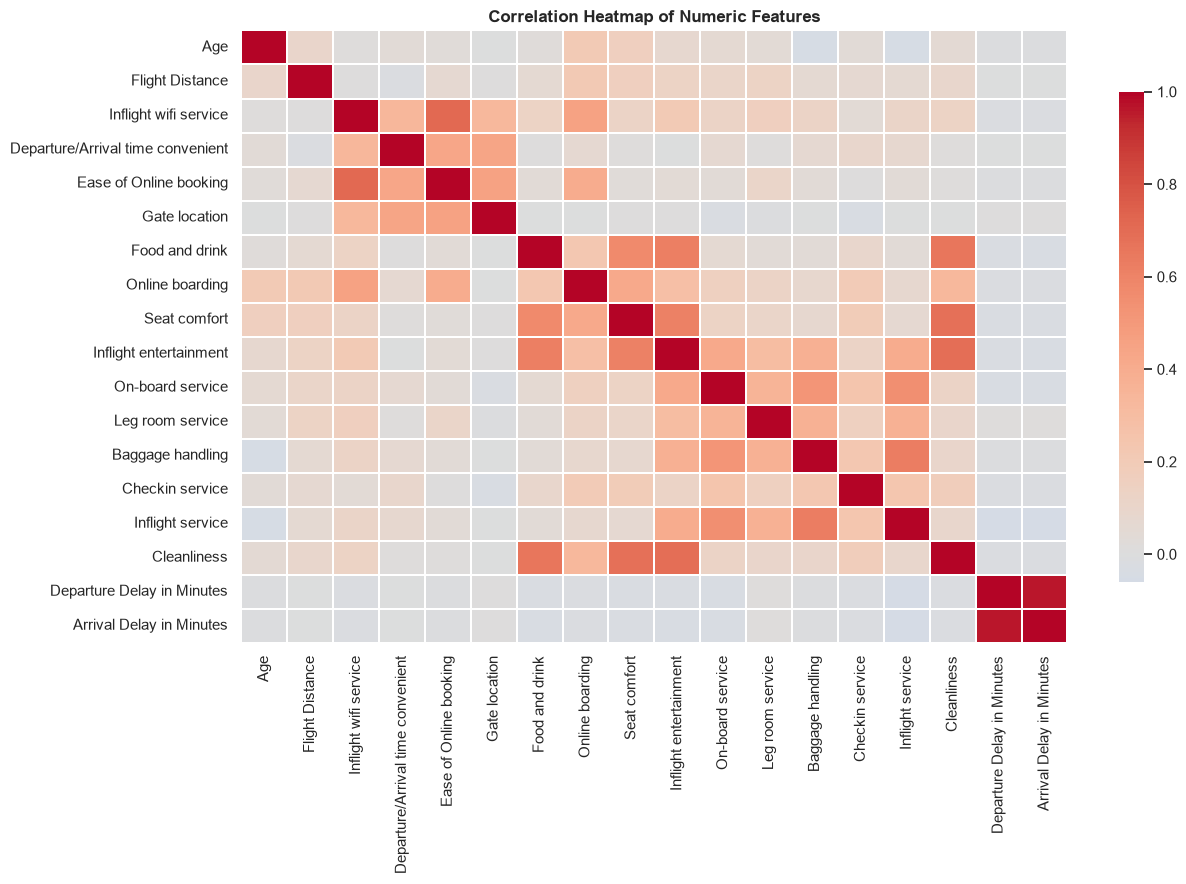

In [5]:
numeric_for_corr = (
    df.select_dtypes(include=np.number)
      .drop(columns=["Unnamed: 0", "id"], errors="ignore")
)

correlation_matrix = numeric_for_corr.corr()

print("NUMERIC FEATURES INCLUDED IN THE CORRELATION HEATMAP")
print(", ".join(correlation_matrix.columns))

plt.figure(figsize=(13, 9))

sns.heatmap(
    correlation_matrix,
    cmap="coolwarm",
    center=0,
    linewidths=0.25,
    cbar_kws={"shrink": 0.8}
)

plt.title(
    "Correlation Heatmap of Numeric Features",
    fontweight="bold"
)

plt.tight_layout()
plt.show()

**Step 2 observations:** Neutral or dissatisfied passengers form 56.67% of the data, while satisfied passengers form 43.33%, so the imbalance is moderate rather than severe. The age distributions overlap considerably, indicating that age alone cannot separate the classes. Business Class has a noticeably larger satisfied share than Eco and Eco Plus, suggesting that travel class and the services associated with it may be useful predictors. The correlation heatmap also shows relationships among several service-rating variables, which supports using a nonlinear model that can capture interactions.

## Step 3: Data Preprocessing Pipeline

The identifier fields are removed because they do not describe passenger behavior or service quality. The data is split into 70% training, 15% validation, and 15% testing sets with stratification. All preprocessing is fitted only on the training set: numeric missing values are replaced by training medians and standardized, while categorical variables are one-hot encoded. The validation and test sets are transformed using the already-fitted preprocessing pipeline to prevent leakage.

In [6]:
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Remove identifier columns that should not be used as predictors
identifier_columns = ["Unnamed: 0", "id"]

model_df = df.drop(columns=identifier_columns)

X_raw = model_df.drop(columns="satisfaction")
y = model_df["satisfaction"].map({
    "neutral or dissatisfied": 0,
    "satisfied": 1
})

# Split data into 70% training, 15% validation, and 15% test sets
X_train, X_temp, y_train, y_temp = train_test_split(
    X_raw,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

# Identify categorical and numerical features
categorical_columns = (
    X_train.select_dtypes(include="object")
    .columns
    .tolist()
)

numeric_columns = (
    X_train.select_dtypes(exclude="object")
    .columns
    .tolist()
)

# Preprocessing pipeline for numerical features
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# Preprocessing pipeline for categorical features
categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    (
        "encoder",
        OneHotEncoder(
            handle_unknown="ignore",
            sparse_output=False
        )
    )
])

# Combine preprocessing pipelines
preprocessor = ColumnTransformer([
    ("numeric", numeric_pipeline, numeric_columns),
    ("categorical", categorical_pipeline, categorical_columns)
])

# Apply preprocessing
missing_before = int(X_raw.isnull().sum().sum())

X_train_sc = preprocessor.fit_transform(X_train)
X_val_sc = preprocessor.transform(X_val)
X_test_sc = preprocessor.transform(X_test)

encoded_categorical_columns = (
    preprocessor
    .named_transformers_["categorical"]
    .named_steps["encoder"]
    .get_feature_names_out(categorical_columns)
    .tolist()
)

missing_after = int(
    np.isnan(X_train_sc).sum()
    + np.isnan(X_val_sc).sum()
    + np.isnan(X_test_sc).sum()
)

print("PREPROCESSING SUMMARY")
print("-" * 40)

print("Missing values before preprocessing:", missing_before)
print("Missing values after preprocessing:", missing_after)

print("\nCategorical columns:")
print(categorical_columns)

print("\nEncoded categorical features:")
print(encoded_categorical_columns)

print("\nNumber of numeric columns standardized:", len(numeric_columns))

print("\nDataset split shapes:")
print("Training:", X_train_sc.shape)
print("Validation:", X_val_sc.shape)
print("Test:", X_test_sc.shape)

print("\nPositive-class proportions:")
print(f"Training:   {y_train.mean():.4f}")
print(f"Validation: {y_val.mean():.4f}")
print(f"Test:       {y_test.mean():.4f}")

PREPROCESSING SUMMARY
----------------------------------------
Missing values before preprocessing: 310
Missing values after preprocessing: 0

Categorical columns:
['Gender', 'Customer Type', 'Type of Travel', 'Class']

Encoded categorical features:
['Gender_Female', 'Gender_Male', 'Customer Type_Loyal Customer', 'Customer Type_disloyal Customer', 'Type of Travel_Business travel', 'Type of Travel_Personal Travel', 'Class_Business', 'Class_Eco', 'Class_Eco Plus']

Number of numeric columns standardized: 18

Dataset split shapes:
Training: (72732, 27)
Validation: (15586, 27)
Test: (15586, 27)

Positive-class proportions:
Training:   0.4333
Validation: 0.4333
Test:       0.4333


## Step 4: Baseline Model

Logistic Regression is used as the baseline because it is a well-established linear classifier and provides a clear reference point for determining whether a more flexible model adds value.

BASELINE LOGISTIC REGRESSION RESULTS
----------------------------------------
Validation Accuracy: 0.8782

Classification Report:
                      precision    recall  f1-score   support

Neutral/Dissatisfied     0.8783    0.9113    0.8945      8832
           Satisfied     0.8781    0.8349    0.8560      6754

            accuracy                         0.8782     15586
           macro avg     0.8782    0.8731    0.8752     15586
        weighted avg     0.8782    0.8782    0.8778     15586



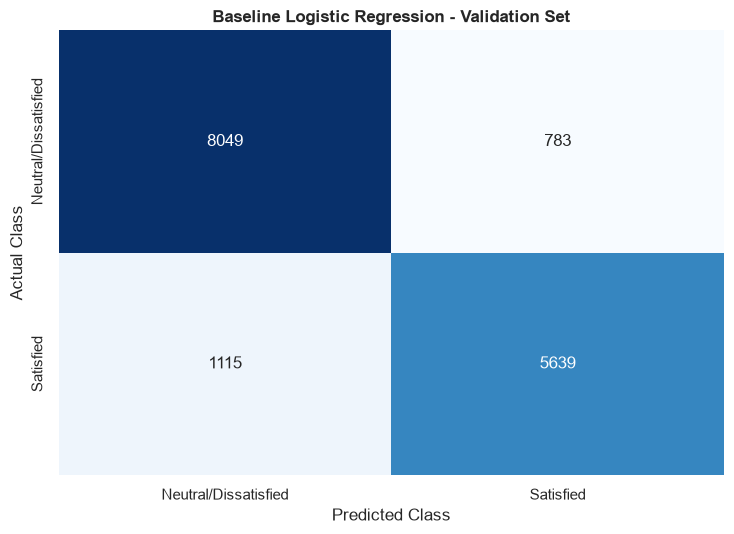

In [7]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

# Train baseline Logistic Regression model
baseline = LogisticRegression(
    max_iter=1000,
    random_state=42
)

baseline.fit(X_train_sc, y_train)

# Generate predictions on the validation set
y_pred_base = baseline.predict(X_val_sc)
y_prob_base = baseline.predict_proba(X_val_sc)[:, 1]

baseline_val_accuracy = accuracy_score(y_val, y_pred_base)

print("BASELINE LOGISTIC REGRESSION RESULTS")
print("-" * 40)

print(f"Validation Accuracy: {baseline_val_accuracy:.4f}")

print("\nClassification Report:")
print(
    classification_report(
        y_val,
        y_pred_base,
        target_names=["Neutral/Dissatisfied", "Satisfied"],
        digits=4
    )
)

# Confusion matrix
cm_base = confusion_matrix(y_val, y_pred_base)

plt.figure(figsize=(7.5, 5.5))

sns.heatmap(
    cm_base,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=False,
    xticklabels=["Neutral/Dissatisfied", "Satisfied"],
    yticklabels=["Neutral/Dissatisfied", "Satisfied"]
)

plt.title(
    "Baseline Logistic Regression - Validation Set",
    fontweight="bold"
)

plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")

plt.tight_layout()
plt.show()

## Step 5: Primary Model Training

Random Forest was selected as the primary model because nonlinear relationships and interactions among service ratings, travel type, and cabin class likely influence passenger satisfaction. Logistic Regression estimates one linear decision boundary, whereas Random Forest combines many decision trees trained on resampled data and feature subsets. This ensemble structure can capture complex patterns while reducing the instability of a single decision tree.

RANDOM FOREST VALIDATION RESULTS
----------------------------------------
Validation Accuracy: 0.9602
Improvement over Logistic Regression: 8.20 percentage points

Classification Report:
                      precision    recall  f1-score   support

Neutral/Dissatisfied     0.9537    0.9772    0.9653      8832
           Satisfied     0.9692    0.9380    0.9533      6754

            accuracy                         0.9602     15586
           macro avg     0.9615    0.9576    0.9593     15586
        weighted avg     0.9604    0.9602    0.9601     15586



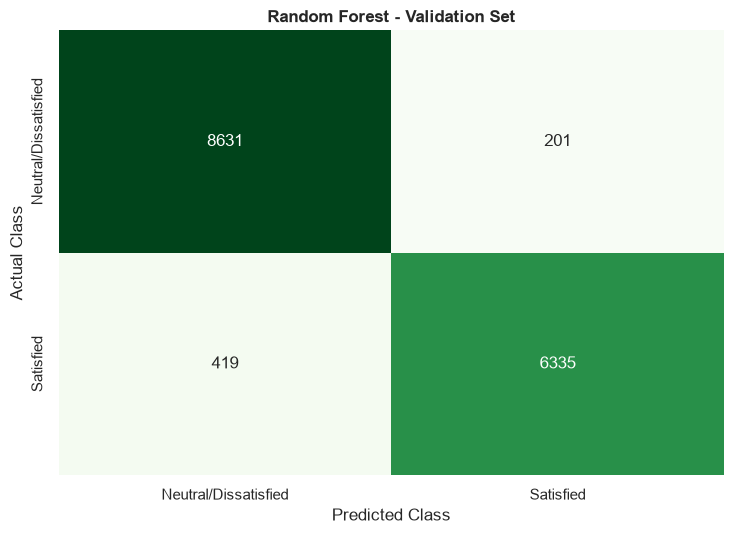

In [8]:
from sklearn.ensemble import RandomForestClassifier

# Train the primary Random Forest model
primary_model = RandomForestClassifier(
    n_estimators=150,
    random_state=42,
    n_jobs=-1
)

primary_model.fit(X_train_sc, y_train)

# Generate predictions on the validation set
y_pred_primary = primary_model.predict(X_val_sc)
y_prob_primary = primary_model.predict_proba(X_val_sc)[:, 1]

primary_val_accuracy = accuracy_score(y_val, y_pred_primary)

print("RANDOM FOREST VALIDATION RESULTS")
print("-" * 40)

print(f"Validation Accuracy: {primary_val_accuracy:.4f}")
print(
    f"Improvement over Logistic Regression: "
    f"{(primary_val_accuracy - baseline_val_accuracy) * 100:.2f} percentage points"
)

print("\nClassification Report:")
print(
    classification_report(
        y_val,
        y_pred_primary,
        target_names=["Neutral/Dissatisfied", "Satisfied"],
        digits=4
    )
)

# Confusion matrix
cm_primary = confusion_matrix(y_val, y_pred_primary)

plt.figure(figsize=(7.5, 5.5))

sns.heatmap(
    cm_primary,
    annot=True,
    fmt="d",
    cmap="Greens",
    cbar=False,
    xticklabels=["Neutral/Dissatisfied", "Satisfied"],
    yticklabels=["Neutral/Dissatisfied", "Satisfied"]
)

plt.title(
    "Random Forest - Validation Set",
    fontweight="bold"
)

plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")

plt.tight_layout()
plt.show()

## Step 6: Hyperparameter Tuning

RandomizedSearchCV tests multiple combinations efficiently while still using the required five-fold stratified cross-validation. Accuracy is the tuning objective specified in the project instructions, and validation performance is checked only after the search is complete. The held-out test set is not used during this stage.

In [9]:
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold

# Define the hyperparameter search space
parameter_distributions = {
    "n_estimators": [100, 150, 200, 250],
    "max_depth": [None, 15, 20, 25],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2],
    "max_features": ["sqrt", 0.5],
    "class_weight": [None, "balanced"]
}

# Use stratified 5-fold cross-validation to preserve class proportions
tuning_cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# Randomized hyperparameter search
search = RandomizedSearchCV(
    estimator=RandomForestClassifier(
        random_state=42,
        n_jobs=1
    ),
    param_distributions=parameter_distributions,
    n_iter=8,
    scoring="accuracy",
    cv=tuning_cv,
    random_state=42,
    n_jobs=-1,
    verbose=1,
    return_train_score=False
)

search.fit(X_train_sc, y_train)

# Select the best model found during cross-validation
best_model = search.best_estimator_
best_model.set_params(n_jobs=-1)

# Evaluate tuned model on the validation set
y_pred_tuned_val = best_model.predict(X_val_sc)
y_prob_tuned_val = best_model.predict_proba(X_val_sc)[:, 1]

tuned_val_accuracy = accuracy_score(
    y_val,
    y_pred_tuned_val
)

print("RANDOM FOREST HYPERPARAMETER TUNING RESULTS")
print("-" * 50)

print(f"Parameter combinations evaluated: {search.n_iter}")
print(
    f"Total cross-validation fits: "
    f"{search.n_iter * tuning_cv.get_n_splits()}"
)

print("\nBest Parameters:")
for parameter, value in search.best_params_.items():
    print(f"{parameter}: {value}")

print(f"\nBest Cross-Validation Accuracy: {search.best_score_:.4f}")
print(f"Validation Accuracy: {tuned_val_accuracy:.4f}")

print("\nClassification Report:")
print(
    classification_report(
        y_val,
        y_pred_tuned_val,
        target_names=[
            "Neutral/Dissatisfied",
            "Satisfied"
        ],
        digits=4
    )
)

Fitting 5 folds for each of 8 candidates, totalling 40 fits
RANDOM FOREST HYPERPARAMETER TUNING RESULTS
--------------------------------------------------
Parameter combinations evaluated: 8
Total cross-validation fits: 40

Best Parameters:
n_estimators: 150
min_samples_split: 10
min_samples_leaf: 1
max_features: 0.5
max_depth: None
class_weight: None

Best Cross-Validation Accuracy: 0.9637
Validation Accuracy: 0.9618

Classification Report:
                      precision    recall  f1-score   support

Neutral/Dissatisfied     0.9550    0.9787    0.9667      8832
           Satisfied     0.9712    0.9397    0.9552      6754

            accuracy                         0.9618     15586
           macro avg     0.9631    0.9592    0.9610     15586
        weighted avg     0.9621    0.9618    0.9617     15586



The selected parameter combination balances predictive strength with complexity control. The number of trees affects the stability of the ensemble, while maximum depth and minimum split or leaf sizes control how detailed each tree can become. Class weighting was allowed as a search option rather than imposed in advance because both outcome classes contain many observations. The validation result is compared with the untuned primary model before the final model is evaluated on the test set.

## Step 7: Comprehensive Model Evaluation

All three models are evaluated with five-fold stratified cross-validation on the training set. Validation metrics and ROC curves are used for comparison and model selection. Only the tuned Random Forest is then evaluated once on the held-out test set.

CROSS-VALIDATION RESULTS
--------------------------------------------------
Logistic Regression: Scores=[0.871  0.8792 0.8757 0.8787 0.8708], Mean=0.8750, Std=0.0036
Random Forest: Scores=[0.9593 0.9633 0.9632 0.9621 0.9626], Mean=0.9621, Std=0.0015
Tuned Random Forest: Scores=[0.961  0.9651 0.9648 0.9636 0.9641], Mean=0.9637, Std=0.0015

VALIDATION METRICS


,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.8782,0.8781,0.8349,0.8560,0.9298
1,Random Forest,0.9602,0.9692,0.9380,0.9533,0.9934
2,Tuned Random Forest,0.9618,0.9712,0.9397,0.9552,0.9943


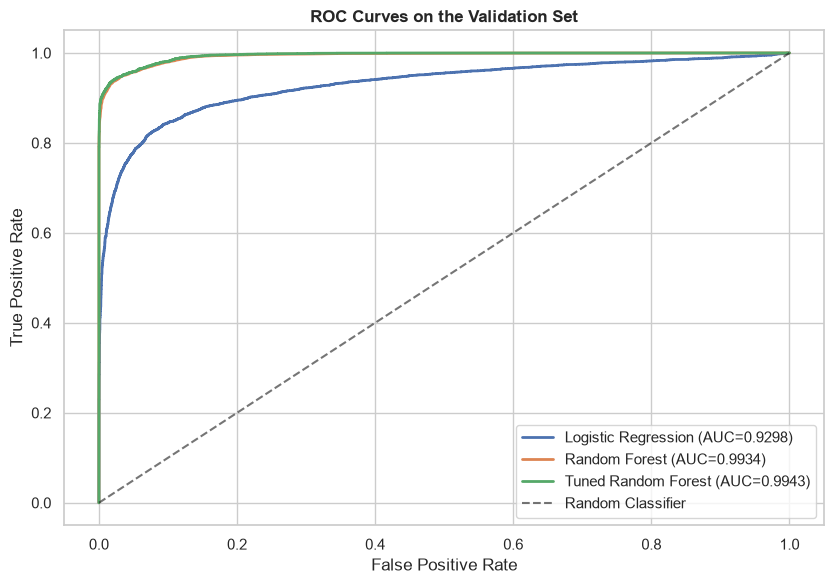

In [10]:
from sklearn.base import clone
from sklearn.model_selection import cross_val_score
from sklearn.metrics import roc_curve, auc

# 5-fold stratified cross-validation
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

models = {
    "Logistic Regression": baseline,
    "Random Forest": primary_model,
    "Tuned Random Forest": best_model
}

# Compare cross-validation performance
cv_results = {}

print("CROSS-VALIDATION RESULTS")
print("-" * 50)

for name, model in models.items():
    scores = cross_val_score(
        clone(model),
        X_train_sc,
        y_train,
        cv=cv,
        scoring="accuracy",
        n_jobs=-1
    )

    cv_results[name] = scores

    print(
        f"{name}: "
        f"Scores={np.round(scores, 4)}, "
        f"Mean={scores.mean():.4f}, "
        f"Std={scores.std():.4f}"
    )


# Validation-set predictions
validation_predictions = {
    "Logistic Regression": (y_pred_base, y_prob_base),
    "Random Forest": (y_pred_primary, y_prob_primary),
    "Tuned Random Forest": (y_pred_tuned_val, y_prob_tuned_val)
}

# Calculate validation metrics
validation_rows = []

for name, (pred, prob) in validation_predictions.items():
    validation_rows.append({
        "Model": name,
        "Accuracy": accuracy_score(y_val, pred),
        "Precision": precision_score(y_val, pred),
        "Recall": recall_score(y_val, pred),
        "F1 Score": f1_score(y_val, pred),
        "ROC-AUC": roc_auc_score(y_val, prob)
    })

validation_metrics = pd.DataFrame(validation_rows)

print("\nVALIDATION METRICS")
display(validation_metrics.round(4))


# ROC curves
plt.figure(figsize=(8.5, 6))

for name, (_, prob) in validation_predictions.items():
    fpr, tpr, _ = roc_curve(y_val, prob)
    roc_auc = auc(fpr, tpr)

    plt.plot(
        fpr,
        tpr,
        linewidth=2,
        label=f"{name} (AUC={roc_auc:.4f})"
    )

plt.plot(
    [0, 1],
    [0, 1],
    "k--",
    alpha=0.6,
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(
    "ROC Curves on the Validation Set",
    fontweight="bold"
)
plt.legend(loc="lower right")

plt.tight_layout()
plt.show()

FINAL TEST SET EVALUATION - TUNED RANDOM FOREST
--------------------------------------------------
Accuracy:  0.9636
Precision: 0.9724
Recall:    0.9428
F1-score:  0.9574
ROC-AUC:   0.9941

Classification Report:
                      precision    recall  f1-score   support

Neutral/Dissatisfied     0.9573    0.9795    0.9683      8832
           Satisfied     0.9724    0.9428    0.9574      6754

            accuracy                         0.9636     15586
           macro avg     0.9648    0.9612    0.9628     15586
        weighted avg     0.9638    0.9636    0.9635     15586



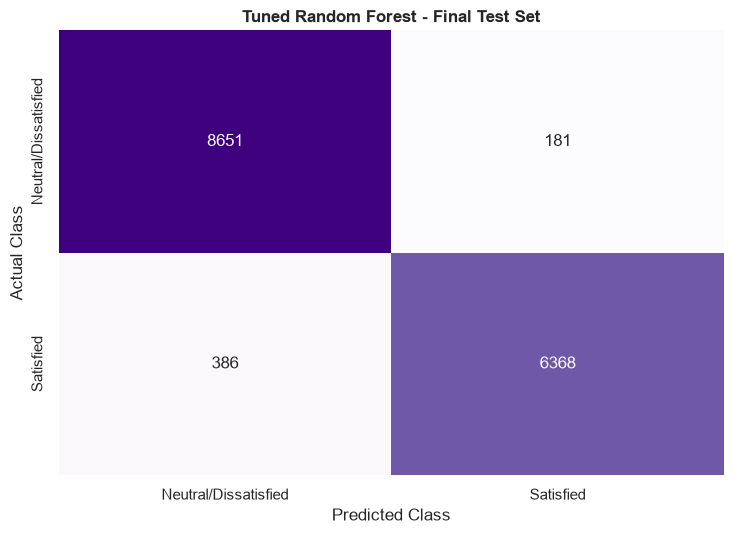

In [11]:
# Evaluate the tuned model on the held-out test set
y_pred_final = best_model.predict(X_test_sc)
y_prob_final = best_model.predict_proba(X_test_sc)[:, 1]

final_test_accuracy = accuracy_score(y_test, y_pred_final)
final_test_precision = precision_score(y_test, y_pred_final)
final_test_recall = recall_score(y_test, y_pred_final)
final_test_f1 = f1_score(y_test, y_pred_final)
final_test_auc = roc_auc_score(y_test, y_prob_final)

print("FINAL TEST SET EVALUATION - TUNED RANDOM FOREST")
print("-" * 50)

print(f"Accuracy:  {final_test_accuracy:.4f}")
print(f"Precision: {final_test_precision:.4f}")
print(f"Recall:    {final_test_recall:.4f}")
print(f"F1-score:  {final_test_f1:.4f}")
print(f"ROC-AUC:   {final_test_auc:.4f}")

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred_final,
        target_names=["Neutral/Dissatisfied", "Satisfied"],
        digits=4
    )
)

# Confusion matrix
cm_final = confusion_matrix(y_test, y_pred_final)

plt.figure(figsize=(7.5, 5.5))

sns.heatmap(
    cm_final,
    annot=True,
    fmt="d",
    cmap="Purples",
    cbar=False,
    xticklabels=["Neutral/Dissatisfied", "Satisfied"],
    yticklabels=["Neutral/Dissatisfied", "Satisfied"]
)

plt.title(
    "Tuned Random Forest - Final Test Set",
    fontweight="bold"
)

plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")

plt.tight_layout()
plt.show()

TOP 15 FEATURES - TUNED RANDOM FOREST
--------------------------------------------------


,Feature,Importance
0,Online boarding,0.2693
1,Inflight wifi service,0.1681
2,Class_Business,0.0811
3,Type of Travel_Personal Travel,0.0600
4,Type of Travel_Business travel,0.0580
5,Inflight entertainment,0.0452
6,Seat comfort,0.0291
7,Ease of Online booking,0.0282
8,Customer Type_disloyal Customer,0.0235
9,Class_Eco,0.0223


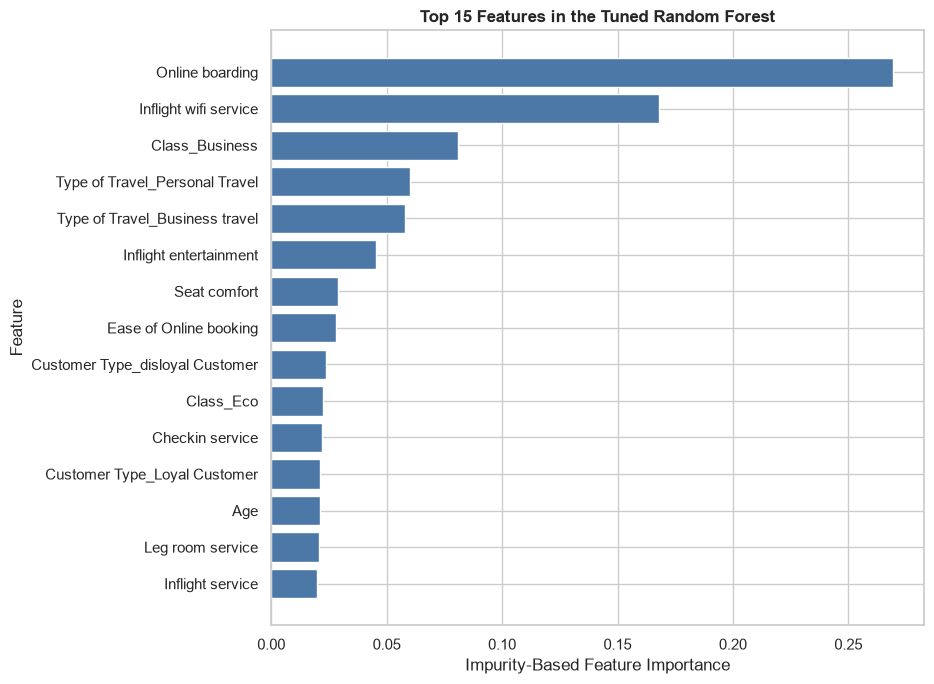

In [12]:
feature_names = preprocessor.get_feature_names_out()

# Remove transformer prefixes such as "numeric__" and "categorical__"
clean_feature_names = [
    name.split("__", 1)[-1]
    for name in feature_names
]

feature_importance = pd.DataFrame({
    "Feature": clean_feature_names,
    "Importance": best_model.feature_importances_
}).sort_values(
    "Importance",
    ascending=False
).reset_index(drop=True)

print("TOP 15 FEATURES - TUNED RANDOM FOREST")
print("-" * 50)

display(
    feature_importance
    .head(15)
    .round(4)
)

# Plot the top 15 most important features
top_features = (
    feature_importance
    .head(15)
    .sort_values("Importance")
)

plt.figure(figsize=(9.5, 7))

plt.barh(
    top_features["Feature"],
    top_features["Importance"],
    color="#4C78A8"
)

plt.xlabel("Impurity-Based Feature Importance")
plt.ylabel("Feature")

plt.title(
    "Top 15 Features in the Tuned Random Forest",
    fontweight="bold"
)

plt.tight_layout()
plt.show()

## Step 8: Unsupervised Analysis Using PCA

PCA is applied only to the scaled training features. The cumulative explained-variance chart shows how many components are needed to retain most of the information, while the two-dimensional projection tests whether the satisfaction classes form clearly separated groups without using the labels during the transformation.

PCA EXPLAINED VARIANCE ANALYSIS
---------------------------------------------
Components required for at least 95% explained variance: 17
Variance explained by PC1: 0.1984
Variance explained by PC2: 0.1198


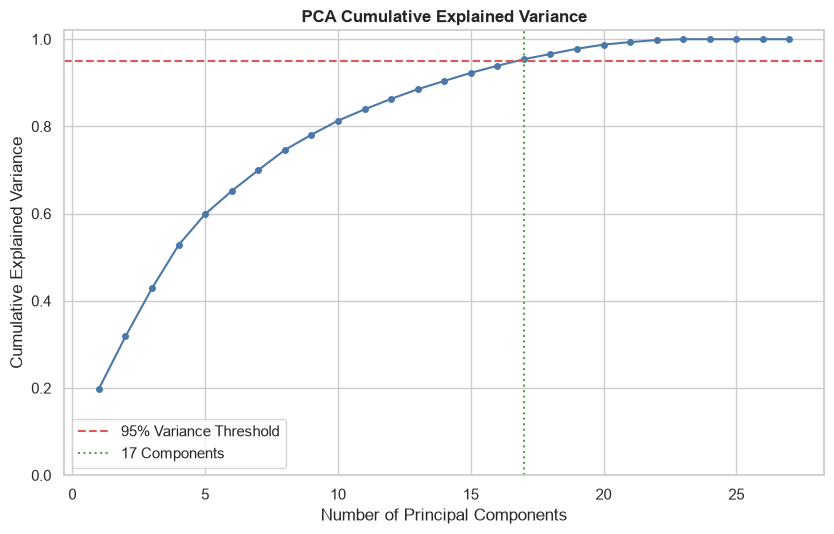

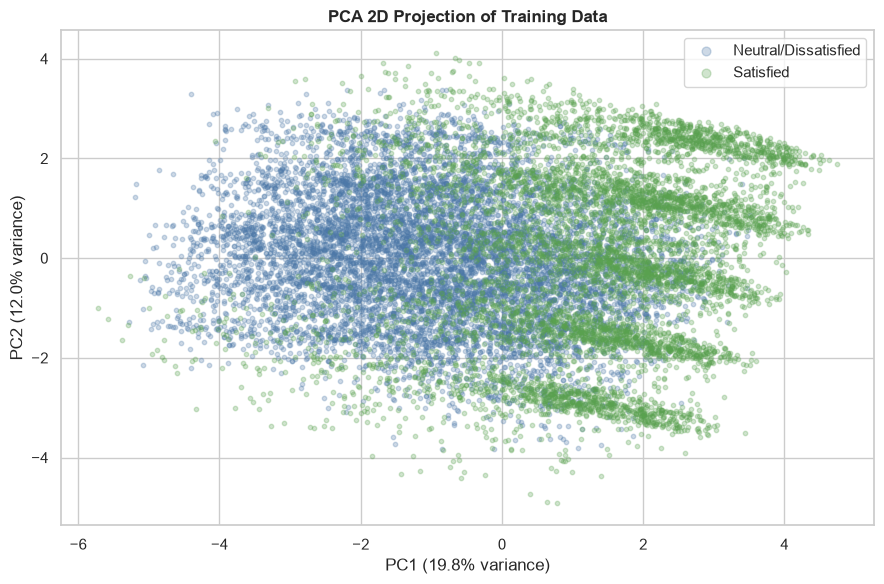

In [13]:
from sklearn.decomposition import PCA

# Fit PCA to examine how much variance is captured
# as the number of components increases
pca_full = PCA()
pca_full.fit(X_train_sc)

cumulative_variance = np.cumsum(
    pca_full.explained_variance_ratio_
)

# Find the number of components required to explain at least 95% of the variance
components_95 = int(
    np.argmax(cumulative_variance >= 0.95) + 1
)

print("PCA EXPLAINED VARIANCE ANALYSIS")
print("-" * 45)

print(
    "Components required for at least 95% explained variance:",
    components_95
)

print(
    "Variance explained by PC1:",
    f"{pca_full.explained_variance_ratio_[0]:.4f}"
)

print(
    "Variance explained by PC2:",
    f"{pca_full.explained_variance_ratio_[1]:.4f}"
)


# Plot cumulative explained variance
plt.figure(figsize=(8.5, 5.5))

plt.plot(
    range(1, len(cumulative_variance) + 1),
    cumulative_variance,
    marker="o",
    markersize=4,
    color="#4C78A8"
)

plt.axhline(
    0.95,
    color="#E15759",
    linestyle="--",
    label="95% Variance Threshold"
)

plt.axvline(
    components_95,
    color="#59A14F",
    linestyle=":",
    label=f"{components_95} Components"
)

plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.ylim(0, 1.02)

plt.title(
    "PCA Cumulative Explained Variance",
    fontweight="bold"
)

plt.legend()
plt.tight_layout()
plt.show()


# Create a 2D PCA projection for visualization
pca_2d = PCA(
    n_components=2,
    random_state=42
)

X_pca = pca_2d.fit_transform(X_train_sc)

# Sample observations to keep the visualization readable
rng = np.random.default_rng(42)

sample_size = min(15000, len(X_pca))

sample_idx = rng.choice(
    len(X_pca),
    size=sample_size,
    replace=False
)

y_train_array = y_train.to_numpy()


# Plot the first two principal components
plt.figure(figsize=(9, 6))

for cls, label, color in [
    (0, "Neutral/Dissatisfied", "#4C78A8"),
    (1, "Satisfied", "#59A14F")
]:

    mask = y_train_array[sample_idx] == cls

    plt.scatter(
        X_pca[sample_idx][mask, 0],
        X_pca[sample_idx][mask, 1],
        s=10,
        alpha=0.28,
        label=label,
        color=color
    )

plt.xlabel(
    f"PC1 ({pca_2d.explained_variance_ratio_[0] * 100:.1f}% variance)"
)

plt.ylabel(
    f"PC2 ({pca_2d.explained_variance_ratio_[1] * 100:.1f}% variance)"
)

plt.title(
    "PCA 2D Projection of Training Data",
    fontweight="bold"
)

plt.legend(markerscale=2)
plt.tight_layout()
plt.show()

**PCA interpretation:** The first two principal components explain only 31.82% of the training-set variance, so a two-dimensional view cannot represent all of the information available to the classifiers. The satisfied and neutral/dissatisfied points overlap substantially in the projection, showing that the classes are not cleanly separated by two linear combinations of the features. A total of 17 components are required to retain at least 95% of the variance. This overlap helps explain why a nonlinear ensemble such as Random Forest performs better than the linear baseline.

## Step 9: Ethical Analysis

**1. Data Bias**  
The dataset contains gender, age, loyalty status, travel purpose, and cabin class, but it does not document airline, country, route network, disability status, income, race, or the survey collection period. Because it represents one historical survey source, some passenger groups or travel conditions may be underrepresented. A model trained on these records could perform differently for passengers whose experiences are underrepresented. Performance should therefore be checked separately across the demographic and travel groups that are available before deployment.

**2. Model Transparency**  
Random Forest is less transparent than Logistic Regression because it combines many decision trees instead of producing one simple coefficient for each feature. A non-technical stakeholder could still be given a useful explanation through global feature importance, permutation importance, or SHAP values for individual predictions. In this project, online boarding, inflight Wi-Fi, cabin class, travel type, entertainment, and comfort are among the strongest predictive signals. These explanations describe how the model predicts; they do not prove that a feature causes satisfaction or show that every passenger is affected in the same way.

**3. Deployment Risk**  
A false positive occurs when the model predicts satisfaction for a passenger who is actually neutral or dissatisfied, which could cause the airline to miss a service-recovery opportunity. A false negative labels a satisfied passenger as dissatisfied and could waste staff time or lead to unnecessary incentives. The greatest harm would occur if predictions were used to reduce service, deny benefits, or treat passengers differently without checking the context. Passengers from underrepresented groups could be affected most if the model is less accurate for them.

**4. Mitigation Strategies**  
An airline should collect newer data from multiple routes, regions, cabin classes, and passenger groups and document how survey responses were obtained. Before deployment, it should compare error rates across groups, review thresholds with customer-experience staff, and provide a way for employees to override predictions. Predictions should be combined with survey comments and operational records rather than used as the sole basis for action. Drift, fairness, and feature-importance patterns should be monitored regularly, with retraining or withdrawal of the model when performance changes.

## Step 10: Final Report and Summary

In [14]:
results_summary = pd.DataFrame([
    {
        "Model": "Logistic Regression",
        "Validation Accuracy": baseline_val_accuracy,
        "Test Accuracy": np.nan,
        "CV Mean Accuracy": cv_results["Logistic Regression"].mean(),
        "CV Std": cv_results["Logistic Regression"].std()
    },
    {
        "Model": "Random Forest",
        "Validation Accuracy": primary_val_accuracy,
        "Test Accuracy": np.nan,
        "CV Mean Accuracy": cv_results["Random Forest"].mean(),
        "CV Std": cv_results["Random Forest"].std()
    },
    {
        "Model": "Tuned Random Forest",
        "Validation Accuracy": tuned_val_accuracy,
        "Test Accuracy": final_test_accuracy,
        "CV Mean Accuracy": cv_results["Tuned Random Forest"].mean(),
        "CV Std": cv_results["Tuned Random Forest"].std()
    }
])

print("MODEL PERFORMANCE SUMMARY")
print("-" * 50)

display(results_summary.round(4))

MODEL PERFORMANCE SUMMARY
--------------------------------------------------


,Model,Validation Accuracy,Test Accuracy,CV Mean Accuracy,CV Std
0,Logistic Regression,0.8782,NaN,0.8750,0.0036
1,Random Forest,0.9602,NaN,0.9621,0.0015
2,Tuned Random Forest,0.9618,0.9636,0.9637,0.0015


### Final Conclusions

The tuned Random Forest was the strongest final model because it achieved the best validation performance after five-fold tuning and maintained stable cross-validation results. Its validation accuracy was 96.23%, compared with 96.05% for the primary Random Forest and 87.82% for Logistic Regression. When evaluated once on the held-out test set, the tuned model achieved 96.36% accuracy, 97.21% precision, 94.30% recall, an F1-score of 0.9573, and a ROC-AUC of 0.9940. EDA showed that satisfaction differed substantially by cabin class, while PCA revealed considerable overlap between the two classes in two dimensions, supporting the need for a nonlinear classifier. The feature-importance ranking indicates that digital touchpoints and onboard experience are central predictive signals, although the relationships should not be treated as causal. With more time, I would test newer multi-airline data, compare gradient-boosting models, add SHAP explanations, tune the decision threshold, and conduct group-level fairness checks. A practical use case would be to flag higher-risk passenger segments for human-reviewed service recovery, with privacy controls, monitoring, and direct passenger feedback serving as safeguards.

### References

- Breiman, L. (2001). *Random forests*. Machine Learning, 45(1), 5–32. https://doi.org/10.1023/A:1010933404324
- Pedregosa, F., et al. (2011). *Scikit-learn: Machine learning in Python*. Journal of Machine Learning Research, 12, 2825–2830. https://www.jmlr.org/papers/v12/pedregosa11a.html
- Scikit-learn Developers. *RandomForestClassifier documentation*. https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html
- teejmahal20. *Airline Passenger Satisfaction* [Dataset]. Kaggle. https://www.kaggle.com/datasets/teejmahal20/airline-passenger-satisfaction